In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## Alternatively: Normalize Cross algorithms in a single environment

normalization_coefficients_cross_alg = {}

for env in data["env_name"].unique():

    env_data = data[(data["env_name"] == env)]

    max_performance = env_data["performance"].max()
    min_performance = env_data["performance"].min()

    coef = 1 / (max_performance - min_performance) if max_performance != min_performance else 1.0
    intercept = -min_performance * coef

    normalization_coefficients_cross_alg[env] = (coef, intercept)

In [4]:
def compute_performance_profile(
    df, 
    tau_values,
    norm_d: dict,
    key: str = "alg-env",
    n_bootstrap: int = 1,
    confidence: float = 0.95
):
    """
    Compute performance profile with bootstrapping:
    - Stratified over envs (always include all envs)
    - Bootstrapped over (config_id, seed) pairs within each env
    
    Returns DataFrame with mean, lower CI, and upper CI.
    """
    results = []
    alpha = (1 - confidence) / 2
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        envs = algo_data["env_name"].unique()
        
        for tau in tau_values:
            bootstrap_scores = []
            
            for _ in range(n_bootstrap):
                env_scores = []
                
                for env in envs:
                    env_data = algo_data[algo_data["env_name"] == env]
                    
                    # Bootstrap sample within this env (sample with replacement)
                    boot_sample = env_data.sample(n=len(env_data), replace=True)
                    
                    HS = len(boot_sample)
                    
                    coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
                    intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
                    
                    indicator_sum = (
                        (boot_sample["performance"] * coef + intercept) > tau
                    ).sum()
                    env_score = indicator_sum / HS
                    env_scores.append(env_score)
                
                # Average over environments (stratified)
                bootstrap_scores.append(np.mean(env_scores))
            
            # Compute statistics
            mean_score = np.mean(bootstrap_scores)
            ci_lower = np.percentile(bootstrap_scores, alpha * 100)
            ci_upper = np.percentile(bootstrap_scores, (1 - alpha) * 100)
            
            results.append({
                "algorithm": algo,
                "tau": tau,
                "performance_profile": mean_score,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper
            })
    
    return pd.DataFrame(results)

In [5]:
def get_tunability(df, percentile):
    tunabilities = []
    algos = []
    envs = []
    for env in df["env_name"].unique():
        for algo in df["algorithm"].unique():
            subset = df[(df["env_name"]==env) & (df["algorithm"]==algo)]
            threshold = subset["last_performance"].quantile(percentile)
            tunability = subset["last_performance"].max() - threshold
            tunabilities.append(tunability)
            algos.append(algo)
            envs.append(env)
    tunabilities = pd.DataFrame({
        "env_name": envs,
        "algorithm": algos,
        "tunability": tunabilities
    })
    return tunabilities

In [6]:
all_tunabilities_list = []

for percentile in np.arange(0, 51)/50:
    tunabilities = get_tunability(data, percentile)
    tunabilities["percentile"] = percentile
    all_tunabilities_list.append(tunabilities)

all_tunabilities = pd.concat(all_tunabilities_list)

# add domain to the dataframe via domain = (env.split("_")[0])
all_tunabilities["domain"] = all_tunabilities["env_name"].apply(lambda env: env.split("_")[0])

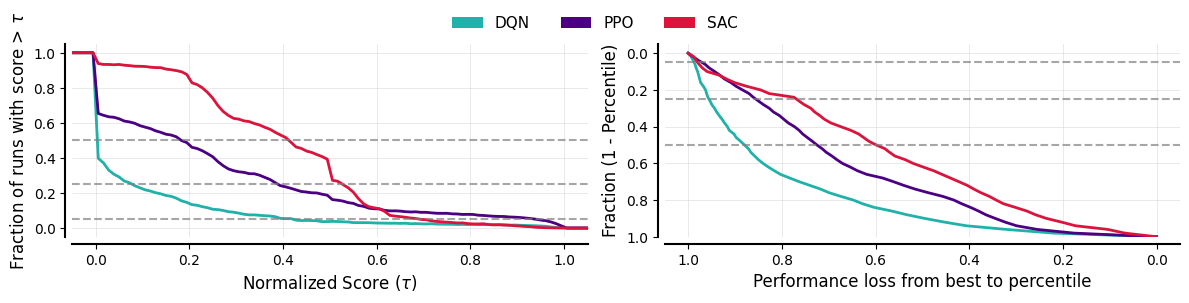

In [7]:
from matplotlib.patches import Patch

tau_min = -.05
tau_max = 1.05
tau_values = np.linspace(tau_min, tau_max, 100)

# Compute performance profiles for cross-algorithm normalization
performance_profiles_cross_alg = compute_performance_profile(data, tau_values, normalization_coefficients_cross_alg, key="env")

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Color palette using cubehelix
palette = sns.cubehelix_palette(n_colors=3)
palette = ["#20b2aa", "indigo", "crimson"]
algo_list = ["dqn", "ppo", "sac"]
algo_colors = {algo: palette[i] for i, algo in enumerate(algo_list)}

# Horizontal threshold values
h_lines = [0.25, 0.50, 0.05]

# Function to style axes
def style_axis(ax):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Make bottom and left spines thicker
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    # Add gap in the corner by adjusting spine positions
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    
    # Add light grey grid
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)  # Grid behind data
    
    # Add horizontal lines
    for h in h_lines:
        ax.axhline(y=h, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# --- Left plot: cross-algorithm normalization (performance profiles) ---
for algo in algo_list:
    algo_data = performance_profiles_cross_alg[performance_profiles_cross_alg["algorithm"] == algo]
    if len(algo_data) > 0:
        ax1.plot(algo_data["tau"], algo_data["performance_profile"], 
                 label=algo.upper(), color=algo_colors.get(algo, None), linewidth=2)
        if "ci_lower" in algo_data.columns and "ci_upper" in algo_data.columns:
            ax1.fill_between(algo_data["tau"], algo_data["ci_lower"], algo_data["ci_upper"], 
                             alpha=0.2, color=algo_colors.get(algo, None))

ax1.set_xlabel(r"Normalized Score ($\tau$)", fontsize=12)
ax1.set_ylabel(r"Fraction of runs with score > $\tau$", fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.set_xlim(tau_min, tau_max)
style_axis(ax1)

# --- Right plot: tunability ---
# Prepare tunability data (assuming all_tunabilities is already computed)
data_ = all_tunabilities.groupby(["algorithm", "percentile"])["tunability"].mean().reset_index()

for algo in algo_list:
    algo_data = data_[data_["algorithm"] == algo].copy()
    # Sort by tunability (x-axis) so the line connects points correctly
    algo_data = algo_data.sort_values("tunability")
    if len(algo_data) > 0:
        ax2.plot(algo_data["tunability"], algo_data["percentile"], 
                 label=algo.upper(), color=algo_colors.get(algo, None), linewidth=2)


ax2.invert_yaxis()
ax2.invert_xaxis()
ax2.set_ylim(1, -0.05)
ax2.set_xlim(1.05, -0.05)
ax2.set_ylabel("Fraction (1 - Percentile)", fontsize=12)
ax2.set_xlabel("Performance loss from best to percentile", fontsize=12)
style_axis(ax2)

# Create joint legend with rectangle patches
legend_elements = [Patch(facecolor=algo_colors[algo], edgecolor='none', label=algo.upper()) 
                   for algo in algo_list]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=11, 
           frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Make room for legend
plt.savefig("_figures/perf_profiles_tunability_combined.pdf", bbox_inches='tight')
plt.show()